In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

df = pd.read_csv("/Users/nurilasalamat/Documents/ml/sis2/archive/diabetes_binary_health_indicators_BRFSS2015.csv") #load the dataset, which mostly consists of imbalanced classes
df.head() #print the first few rows of the dataset to understand its structure

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Dataset Overview

In [3]:
print("Shape:", df.shape)
print("Number of features:", df.shape[1]-1)
print("Target variable: Diabetes_binary")

Shape: (253680, 22)
Number of features: 21
Target variable: Diabetes_binary


In [4]:
#Check for missing values
df.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Perform EDA

In [5]:
#1. Check imbalance
df["Diabetes_binary"].value_counts(normalize=True) * 100 #percentage of each class in the target variable


Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64

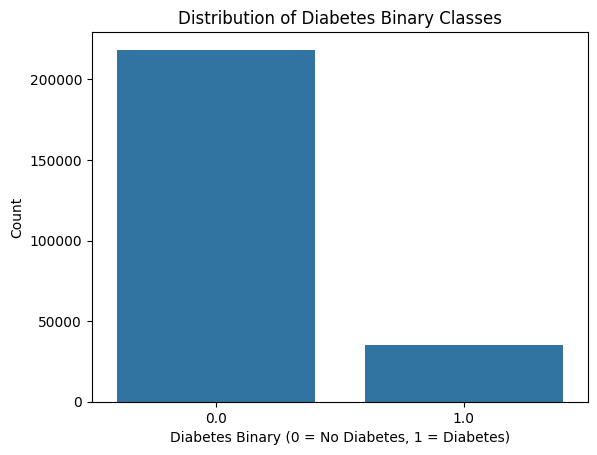

In [6]:
#Visualize the imbalance
sns.countplot(x='Diabetes_binary', data=df)
plt.xlabel('Diabetes Binary (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.title('Distribution of Diabetes Binary Classes')
plt.show()

Here is the clear visualization of imbalance class distribution, showing that negative cases are dominated over the positive class.

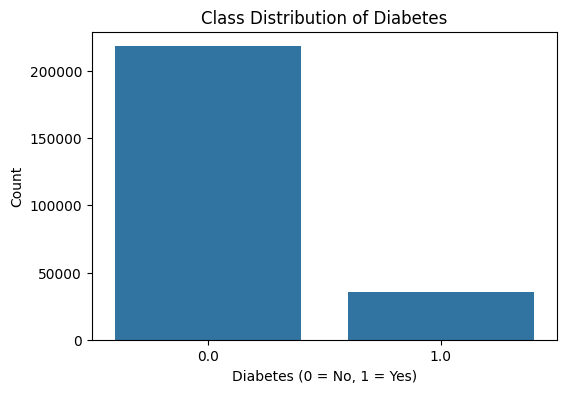

In [7]:
#Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Diabetes_binary', data=df)

plt.title("Class Distribution of Diabetes")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

Feature correlation heatmap

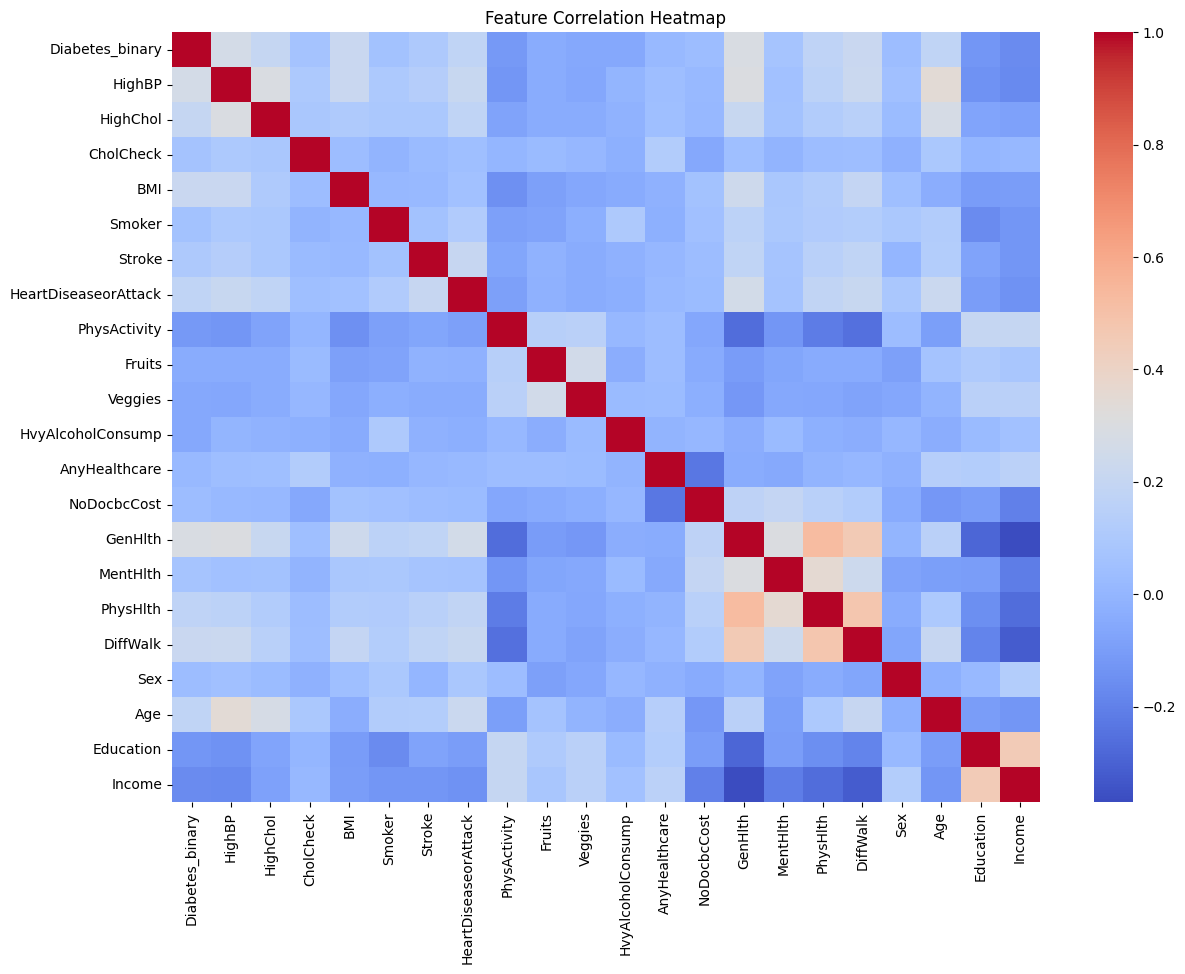

In [8]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

The heatmap shows relationships between health indicators and diabetes status. Features such as BMI, HighBP, and HighChol show stronger correlation with diabetes.

Visualizing key features vs Targets
Example features: BMI, HighBP, HighChol.

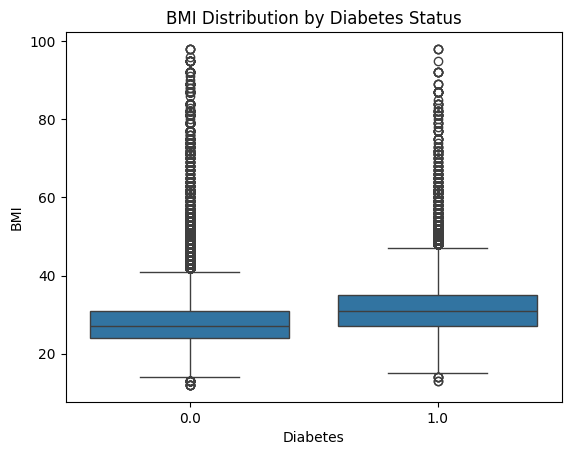

In [9]:
#BMI vs Diabetes_binary
sns.boxplot(x="Diabetes_binary", y="BMI", data=df)

plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("BMI")

plt.show()

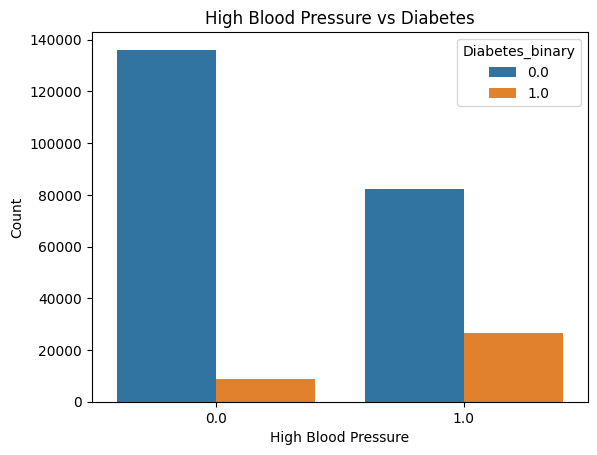

In [10]:
#High Blood Pressure vs Diabetes
sns.countplot(x="HighBP", hue="Diabetes_binary", data=df)

plt.title("High Blood Pressure vs Diabetes")
plt.xlabel("High Blood Pressure")
plt.ylabel("Count")

plt.show()

In [11]:
#Preprocessing data

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
#Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# check duplicates
print("Duplicate rows:", df.duplicated().sum())

# remove if any
df = df.drop_duplicates()

Duplicate rows: 24206


Duplicate rows were checked and removed to avoid bias in the dataset.

In [13]:
#Normalization
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

X_train_norm = minmax.fit_transform(X_train)
X_test_norm = minmax.transform(X_test)

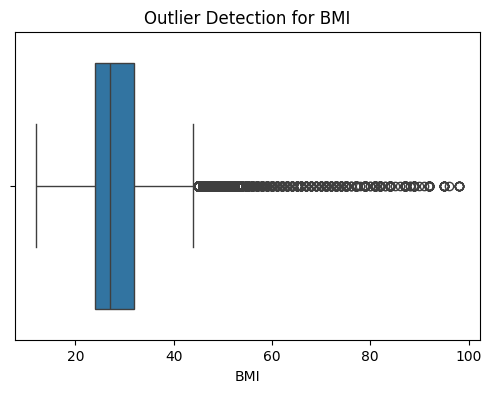

In [14]:
#Outlier detection 
plt.figure(figsize=(6,4))
sns.boxplot(x=df["BMI"])
plt.title("Outlier Detection for BMI")
plt.show()

In [15]:
#Handling Class imbalance
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Original: Diabetes_binary
0.0    174595
1.0     28349
Name: count, dtype: int64
After SMOTE: Diabetes_binary
0.0    174595
1.0    174595
Name: count, dtype: int64


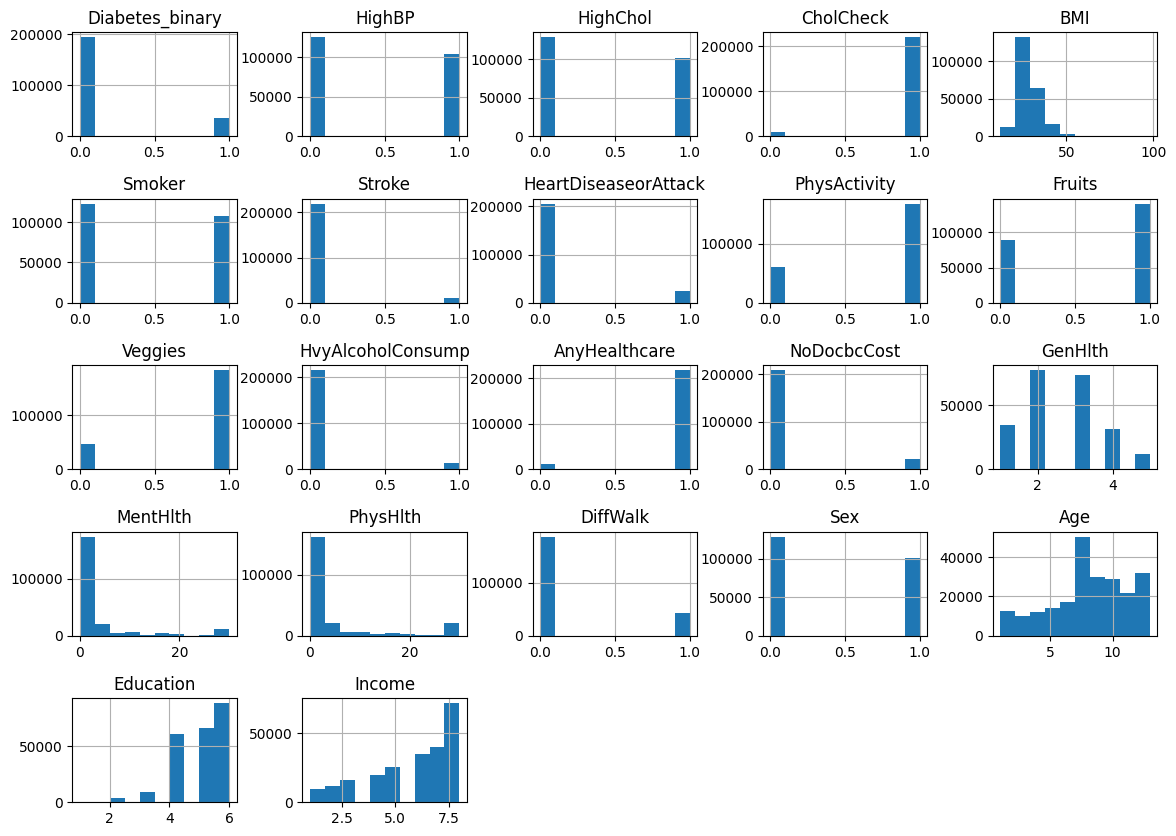

In [16]:
df.hist(figsize=(14,10))
plt.subplots_adjust(
    hspace=0.6,
    wspace=0.4  
)
plt.show()

Logistic Regression

In [17]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:,1]

Decision Tree

In [18]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

Random Forest

In [19]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

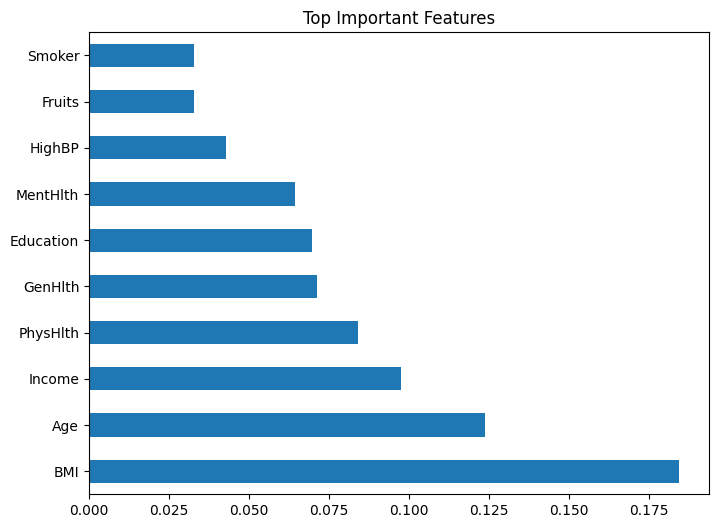

In [20]:
#Feature importance for Random Forest

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()

In [21]:
#kNN
knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)
knn_prob = knn.predict_proba(X_test_scaled)[:,1]

In [22]:
#SVM
from sklearn.svm import LinearSVC

# smaller sample for SVM only
sample_df = df.sample(5000, random_state=42)

X_sample = sample_df.drop("Diabetes_binary", axis=1)
y_sample = sample_df["Diabetes_binary"]

from sklearn.model_selection import train_test_split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train_s)
X_test_s = scaler.transform(X_test_s)

svm = LinearSVC(max_iter=2000)

svm.fit(X_train_s, y_train_s)

svm_pred = svm.predict(X_test_s)

In [23]:
#XGBoost
xgb = XGBClassifier()

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

In [24]:
#Evaluation metrics
def evaluate_model(y_test, pred, prob):

    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("F1 Score:", f1_score(y_test, pred))
    print("ROC AUC:", roc_auc_score(y_test, prob))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, pred))

In [25]:
evaluate_model(y_test, log_pred, log_prob)

Accuracy: 0.8658940397350994
Precision: 0.5454974068835455
Recall: 0.16535658139202516
F1 Score: 0.2537837245009871
ROC AUC: 0.8263596542959625

Confusion Matrix
[[42775   964]
 [ 5840  1157]]


In [26]:
evaluate_model(y_test, dt_pred, dt_prob)

Accuracy: 0.7980526647745191
Precision: 0.2951708485689068
Recall: 0.33457195941117623
F1 Score: 0.31363879957127544
ROC AUC: 0.6016732950480816

Confusion Matrix
[[38149  5590]
 [ 4656  2341]]


In [27]:
evaluate_model(y_test, rf_pred, rf_prob)

Accuracy: 0.8599416587827183
Precision: 0.4784158415841584
Recall: 0.1726454194654852
F1 Score: 0.2537282083595883
ROC AUC: 0.8016053856933647

Confusion Matrix
[[42422  1317]
 [ 5789  1208]]


In [28]:
evaluate_model(y_test, knn_pred, knn_prob)

Accuracy: 0.8468148848943551
Precision: 0.39558070600916195
Recall: 0.20980420180077175
F1 Score: 0.2741875233470303
ROC AUC: 0.7226665647807966

Confusion Matrix
[[41496  2243]
 [ 5529  1468]]


In [29]:
svm_pred = svm.predict(X_test_s)

print("Accuracy:", accuracy_score(y_test_s, svm_pred))
print("Precision:", precision_score(y_test_s, svm_pred))
print("Recall:", recall_score(y_test_s, svm_pred))
print("F1 Score:", f1_score(y_test_s, svm_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_s, svm_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_s, svm_pred))

# ROC-AUC (using decision scores since LinearSVC has no predict_proba)
svm_scores = svm.decision_function(X_test_s)
print("ROC-AUC:", roc_auc_score(y_test_s, svm_scores))


Accuracy: 0.848
Precision: 0.5517241379310345
Recall: 0.1032258064516129
F1 Score: 0.17391304347826086

Confusion Matrix:
[[832  13]
 [139  16]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92       845
         1.0       0.55      0.10      0.17       155

    accuracy                           0.85      1000
   macro avg       0.70      0.54      0.55      1000
weighted avg       0.81      0.85      0.80      1000

ROC-AUC: 0.8335712922313419


In [30]:
evaluate_model(y_test, xgb_pred, xgb_prob)

Accuracy: 0.8670963418479974
Precision: 0.5567470956210903
Recall: 0.17807631842218094
F1 Score: 0.26984298863021117
ROC AUC: 0.831897336057541

Confusion Matrix
[[42747   992]
 [ 5751  1246]]


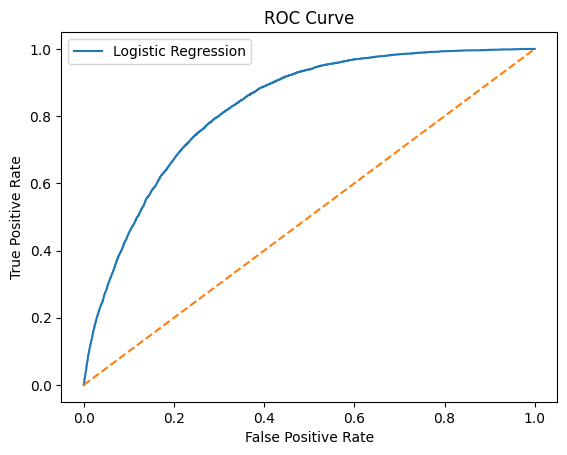

In [31]:
#ROC Curve
fpr, tpr, _ = roc_curve(y_test, log_prob)

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

/Users/nurilasalamat/Documents/ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/nurilasalamat/Documents/ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


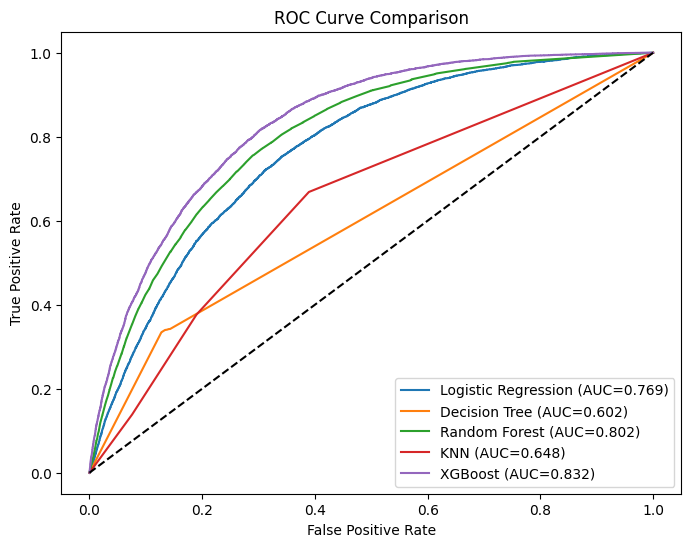

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn,
    "XGBoost": xgb
}

for name, model in models.items():
    
    y_prob = model.predict_proba(X_test)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

# random classifier line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [36]:
svm_scores = svm.decision_function(X_test_s)

from sklearn.metrics import roc_auc_score

print("SVM ROC-AUC:", roc_auc_score(y_test_s, svm_scores))

SVM ROC-AUC: 0.8335712922313419


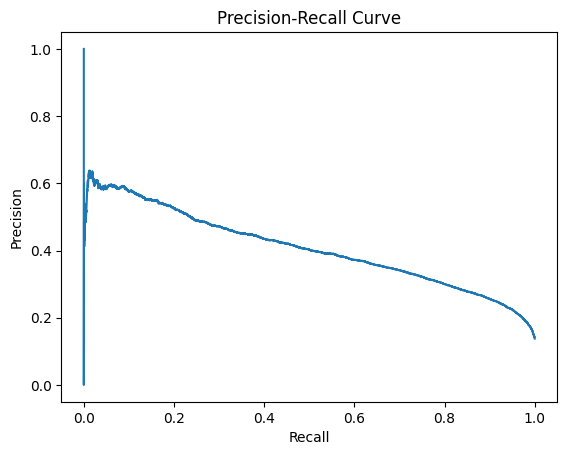

In [33]:
#PRC
precision, recall, _ = precision_recall_curve(y_test, log_prob)

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

/Users/nurilasalamat/Documents/ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/nurilasalamat/Documents/ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


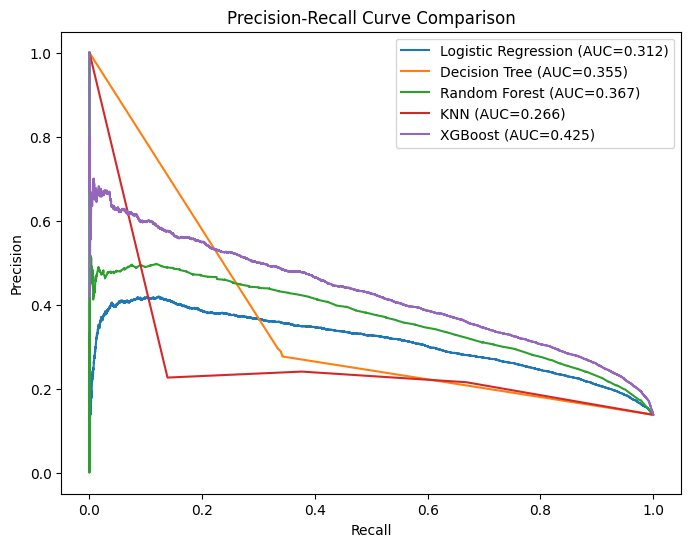

In [37]:
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(8,6))

for name, model in models.items():
    
    y_prob = model.predict_proba(X_test)[:,1]
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

In [38]:
from sklearn.metrics import precision_recall_curve, auc

svm_scores = svm.decision_function(X_test_s)

precision, recall, _ = precision_recall_curve(y_test_s, svm_scores)

pr_auc = auc(recall, precision)

print("SVM PR-AUC:", pr_auc)

SVM PR-AUC: 0.43620974674522134


In [39]:
for name, model in models.items():
    
    y_prob = model.predict_proba(X_test)[:,1]
    
    print(name, "ROC-AUC:", roc_auc_score(y_test, y_prob))

/Users/nurilasalamat/Documents/ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Logistic Regression ROC-AUC: 0.7690236385140915
Decision Tree ROC-AUC: 0.6016732950480816
Random Forest ROC-AUC: 0.8016053856933647


/Users/nurilasalamat/Documents/ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


KNN ROC-AUC: 0.64828827310812
XGBoost ROC-AUC: 0.831897336057541


Several machine learning models were trained to predict diabetes based on health indicators. Logistic Regression provided a strong baseline performance, while tree-based models such as Random Forest and XGBoost captured more complex patterns in the data.
Due to the class imbalance, evaluation metrics such as F1-score, ROC-AUC, precision, and recall were used instead of relying solely on accuracy.
Random Forest and XGBoost achieved the best overall performance, indicating that ensemble methods are well suited for this dataset.

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "Random Forest", "KNN", "SVM", "XGBoost"],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test_s, svm_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC" : [
        roc_auc_score(y_test, log_pred),
        roc_auc_score(y_test, dt_pred),
        roc_auc_score(y_test, rf_pred),
        roc_auc_score(y_test, knn_pred),
        roc_auc_score(y_test_s, svm_pred),
        roc_auc_score(y_test, xgb_pred)
    ]
})
results


,Model,F1 Score,ROC-AUC
0,Logistic,0.253784,0.571658
1,Decision Tree,0.313639,0.603384
2,Random Forest,0.253728,0.571267
3,KNN,0.274188,0.579261
4,SVM,0.173913,0.543921
5,XGBoost,0.269843,0.577698
